# Adaptive memory testing analysis

This notebook reads the PsyNet simulated export and standalone adaptive-policy CSV evidence directly. It summarizes exported trial metadata and checks whether the adaptive policy learns sensible digit-string lengths for synthetic participants.

In [1]:
from ast import literal_eval
from pathlib import Path
from zipfile import ZipFile
import pandas as pd
import matplotlib.pyplot as plt

evidence_dir = Path('..').resolve()
standalone_csv = evidence_dir / 'standalone_simulation' / 'adaptive_policy_simulation.csv'
standalone = pd.read_csv(standalone_csv)
hmc = pd.read_csv(evidence_dir / 'standalone_simulation' / 'hmc_accuracy_comparison.csv')
with ZipFile(evidence_dir / 'simulated_data.zip') as zf:
    with zf.open('regular/data/MemoryRecallTrial.csv') as f:
        exported_trials = pd.read_csv(f)
standalone.head()

,participant_key,true_r,trial_index,adaptive,selected_length,y,p_correct,posterior_r_mean,posterior_r_sd,acquisition_value,fit_ms,score_ms
0,adaptive-01,0.321494,1,True,5,0,0.143124,0.877095,0.565191,0.310452,2938.884050,0.048993
1,adaptive-01,0.321494,2,True,6,0,0.097018,1.003036,0.652377,0.347400,1237.915553,0.026930
2,adaptive-01,0.321494,3,True,6,0,0.097018,1.148346,2.059961,0.774284,1368.431800,0.028325
3,adaptive-01,0.321494,4,True,2,0,0.459499,0.377819,0.250884,0.155047,1395.377575,0.027081
4,adaptive-01,0.321494,5,True,4,0,0.211139,0.693526,0.800555,0.407415,1417.358323,0.027588


In [2]:
exported_trials[['participant_id', 'trial_index', 'selected_length', 'target_string', 'raw_response', 'y', 'posterior_snapshot_id', 'acquisition_value']].head()

,participant_id,trial_index,selected_length,target_string,raw_response,y,posterior_snapshot_id,acquisition_value
0,1,1,5,31236,31236,1,participant-1-n0-s20260614,0.310452
1,1,2,6,580643,580643,1,participant-1-n1-s20260614,0.301773
2,1,3,9,690187744,690187744,1,participant-1-n2-s20260614,0.470915
3,1,4,14,04684567198613,05684567198613,0,participant-1-n3-s20260614,0.619744
4,1,5,13,4354871138698,4394871138698,0,participant-1-n4-s20260614,0.663611


In [3]:
def fit_ms(cell):
    if isinstance(cell, str):
        return literal_eval(cell).get('fit_posterior', 0)
    return 0

export_summary = (exported_trials
    .groupby('participant_id')
    .agg(
        n_trials=('id', 'count'),
        mean_length=('selected_length', 'mean'),
        accuracy=('y', 'mean'),
        final_posterior_r=('posterior_r_mean', 'last'),
        max_fit_ms=('timing_ms', lambda s: max(fit_ms(x) for x in s)),
    )
    .reset_index())
export_summary.head(12)

,participant_id,n_trials,mean_length,accuracy,final_posterior_r,max_fit_ms
0,1,10,8.5,0.4,1.324328,2987.121866
1,2,10,5.0,0.3,1.512756,923.845880
2,3,10,7.4,0.2,0.883941,763.699150
3,4,10,7.9,0.5,1.971972,1005.426267
4,5,10,12.6,0.5,2.179010,803.514065
5,6,10,6.2,0.4,1.651992,797.097687
6,7,10,6.8,0.3,1.526504,777.141666
7,8,10,7.8,0.4,1.244643,1107.613741
8,9,10,12.0,0.6,2.708553,774.554465
9,10,10,12.0,0.8,3.111614,764.793011


In [4]:
summary = (
    standalone.groupby(['adaptive', 'true_r'])
    .agg(
        mean_length=('selected_length', 'mean'),
        final_posterior_r=('posterior_r_mean', 'last'),
        mean_correct=('y', 'mean'),
        mean_fit_ms=('fit_ms', 'mean'),
        max_fit_ms=('fit_ms', 'max'),
    )
    .reset_index()
)
summary

,adaptive,true_r,mean_length,final_posterior_r,mean_correct,mean_fit_ms,max_fit_ms
0,False,0.269518,8.4,NaN,0.3,0.000000,0.000000
1,False,0.321494,11.2,NaN,0.0,0.000000,0.000000
2,False,0.373565,11.5,NaN,0.2,0.000000,0.000000
3,False,0.625796,9.6,NaN,0.1,0.000000,0.000000
4,False,0.681422,11.5,NaN,0.3,0.000000,0.000000
5,False,0.782048,11.3,NaN,0.1,0.000000,0.000000
6,False,0.818028,9.1,NaN,0.4,0.000000,0.000000
7,False,0.902853,9.4,NaN,0.4,0.000000,0.000000
8,False,0.982340,10.8,NaN,0.1,0.000000,0.000000
9,False,0.991616,8.0,NaN,0.4,0.000000,0.000000


In [5]:
hmc_summary = (hmc
    .groupby('adaptive')
    .agg(
        n_participants=('participant_key', 'count'),
        mean_absolute_error=('absolute_error', 'mean'),
        rmse=('squared_error', lambda x: (x.mean()) ** 0.5),
    )
    .reset_index())
hmc_summary

,adaptive,n_participants,mean_absolute_error,rmse
0,False,30,1.651920,1.898298
1,True,30,2.559394,2.612459


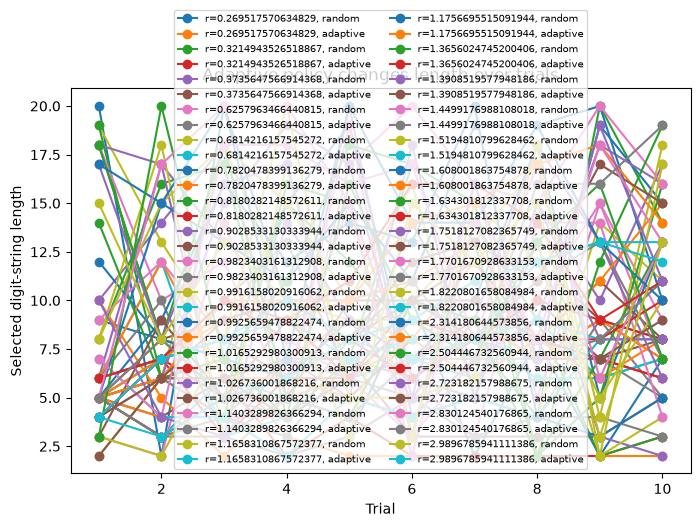

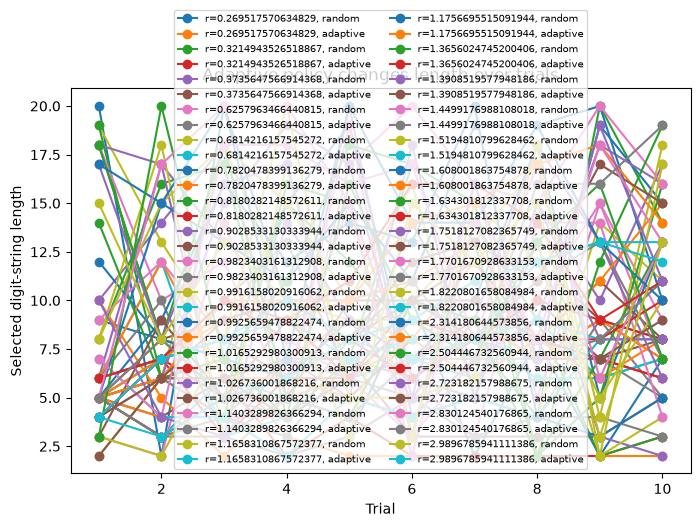

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for (true_r, adaptive), group in standalone.groupby(['true_r', 'adaptive']):
    label = f"r={true_r}, {'adaptive' if adaptive else 'random'}"
    ax.plot(group['trial_index'], group['selected_length'], marker='o', label=label)
ax.set_xlabel('Trial')
ax.set_ylabel('Selected digit-string length')
ax.set_title('Adaptive policy changes length over trials')
ax.legend(fontsize=7, ncol=2)
fig

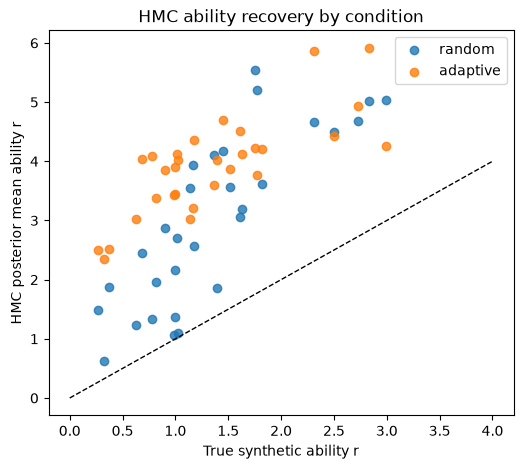

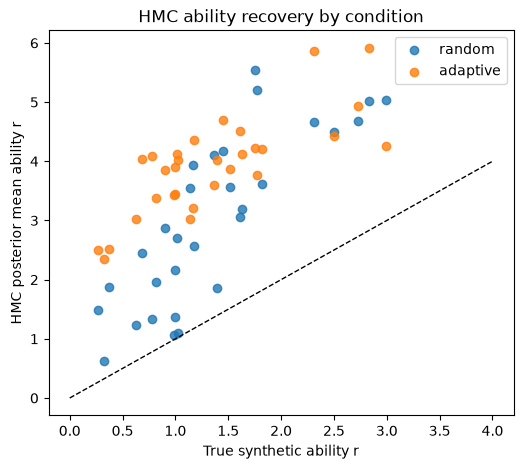

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
for adaptive, group in hmc.groupby('adaptive'):
    label = 'adaptive' if adaptive else 'random'
    ax.scatter(group['true_r'], group['hmc_r_mean'], label=label, alpha=0.8)
ax.plot([0, 4], [0, 4], linestyle='--', color='black', linewidth=1)
ax.set_xlabel('True synthetic ability r')
ax.set_ylabel('HMC posterior mean ability r')
ax.set_title('HMC ability recovery by condition')
ax.legend()
fig

## Interpretation

The PsyNet export should contain 10 finalized trials per participant with target strings, raw responses, exact-match `y`, posterior snapshot IDs, acquisition values, and timing metadata. The standalone simulation contains 30 adaptive and 30 non-adaptive participants, and the HMC table compares participant ability-estimate accuracy between the two conditions. Timing summaries check whether VI fitting and candidate scoring remain within the participant-response budget for this challenge implementation.